In [1]:
# boxplot observation 3.6:

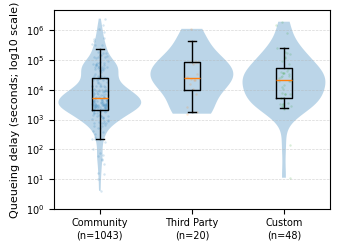

Saved: C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\3 - RQ3\Part_2_Performance\obs36_queue_bean_box_logspace_ieee.png


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base_dir = r"C:\Android Mobile App\Step3_Instr_Testing_Analysis\Type_1\Aug_10\ICST2026\3 - RQ3\Part_2_Performance"
csv_path = os.path.join(base_dir, "run_metrics_v16_stage3_enhanced.csv")
out_path = os.path.join(base_dir, "obs36_queue_bean_box_logspace_ieee.png")

df = pd.read_csv(csv_path)

style_map = {
    "Emu_Community": "Community",
    "Third-Party": "Third Party",
    "Emu_Custom": "Custom",
    "Emu_Community,GMD": "Community+GMD",
}
df = df[df["styles"].isin(style_map)].copy()
df["Style"] = df["styles"].map(style_map)

queued = df[df["queue_seconds"] > 0].copy()

group_order = ["Community", "Third Party", "Custom", "Community+GMD"]

data_log, groups = [], []
for s in group_order:
    vals = queued.loc[queued["Style"] == s, "queue_seconds"].dropna().values
    if len(vals) == 0:
        continue
    data_log.append(np.log10(vals))
    groups.append(s)

# IEEE single-column sizing
plt.figure(figsize=(3.5, 2.6))

# Violin in log space
plt.violinplot(data_log, showmeans=False, showmedians=False, showextrema=False, widths=0.9)

# Boxplot in log space (inside)
plt.boxplot(data_log, widths=0.18, showfliers=False, whis=(5, 95))

# Light jittered points (sampled) in log space
rng = np.random.default_rng(7)
max_points = 220
for i, vals in enumerate(data_log, start=1):
    vals = np.asarray(vals)
    if len(vals) > max_points:
        vals = rng.choice(vals, size=max_points, replace=False)
    jitter = (rng.random(len(vals)) - 0.5) * 0.18
    plt.scatter(i + jitter, vals, s=3, alpha=0.18, linewidths=0)

# X labels
xticklabels = []
for s in groups:
    n = int((queued["Style"] == s).sum())
    xticklabels.append(f"{s}\n(n={n})")
plt.xticks(range(1, len(groups) + 1), xticklabels, fontsize=7)

# Y ticks shown as seconds (10^k)
yticks = np.arange(0, 7)  # 10^0 .. 10^6 seconds
plt.yticks(yticks, [r"$10^{%d}$" % k for k in yticks], fontsize=7)

plt.ylabel("Queueing delay (seconds; log10 scale)", fontsize=8)
#plt.title("Obs. 3.6: Queueing pressure (bean+box, nonzero only)", fontsize=9)
plt.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
